# Polish Companies Bankruptcy Prediction
## 03 - Predictive Modeling

### Objective

The objective is to develop and evaluate models for predicting corporate bankruptcy within a 1 year horizon.

The modeling workflow emphasizes:

- stratified data splitting,
- leakage-safe preprocessing,
- class-imbalance-aware evaluation,
- comparison against simple baselines,
- cross-validation for model selection,
- sensitivity analysis of unusual missing-value signals,
- final evaluation on an untouched test set.

Because bankruptcy represents only approximately 7% of the observations, accuracy will not be used as the primary model selection metric.

In [1]:
# Import libraries

from pathlib import Path
import pandas as pd
import numpy as np
from scipy.io import arff
import matplotlib.pyplot as plt


from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    confusion_matrix,
    brier_score_loss,
    log_loss
)

In [2]:
# Load the original 1 year bankruptcy dataset so that this notebook can run independently from the previous notebooks

DATA_PATH = Path("../data/raw/5year.arff")

raw_data, metadata = arff.loadarff(DATA_PATH)

bankruptcy_1y = pd.DataFrame(raw_data)

bankruptcy_1y["class"] = bankruptcy_1y["class"].apply(lambda x: x.decode("utf-8") if isinstance(x,bytes) else x).astype(int)

bankruptcy_1y = bankruptcy_1y.rename(
    columns= {
        f"Attr{i}": f"X{i}"
        for i in range(1,65)
    }
)

bankruptcy_1y = (
    bankruptcy_1y
    .drop(columns=["index"], errors="ignore")
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"Modeling dataset shape: {bankruptcy_1y.shape}")
print(f"Bankruptcy rate: {bankruptcy_1y['class'].mean():.2%}")

Modeling dataset shape: (5850, 65)
Bankruptcy rate: 6.97%


In [3]:
# Separate financial predictors from the bankruptcy target

X = bankruptcy_1y.drop(columns="class")
y = bankruptcy_1y["class"]

print(f"Features: {X.shape[1]}")
print(f"Observations: {len(X):,}")
print(f"'index' in features: {'index' in X.columns}")
print(f"'class' in features: {'class' in X.columns}")

Features: 64
Observations: 5,850
'index' in features: False
'class' in features: False


In [4]:
#Validate that the modeling matrix contaings exacytly the expected X1-X64 features.

expected_features = {f"X{i}" for i in range(1,65)}

assert set(X.columns) == expected_features, (
    "Unexpected or missing features detected in the modeling matrix."
)

assert X.shape[1] == 64

print("Feature validation passed")

Feature validation passed


In [5]:
# Reserve 20% of the observations as an untouched final test set stratification preserves the minority class proportion in both subsets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.20,
    stratify=y,
    random_state=42
)

print(f"Training observation: {len(X_train):,}")
print(f"Test observations: {len(X_test):,}")
print(f"Training bankruptcy rate: {y_train.mean():.2%}")
print(f"Test bankruptcy rate: {y_test.mean():.2%}")

Training observation: 4,680
Test observations: 1,170
Training bankruptcy rate: 6.97%
Test bankruptcy rate: 7.01%


In [6]:
#Verify that stratification preseved enough bankrupt companies in both the training and final test sets

split_summary = pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index()
})

split_summary.index = [
    "Non-Bankrupt",
    "Bankrupt"
]

split_summary

,train,test
Non-Bankrupt,4354,1088
Bankrupt,326,82


In [7]:
# Define stratifed 5 fold cross validation for model comparison. Each fold preserves approximately the same bankruptcy proportion.

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [8]:
# Create a non skill baseline that predicts according to the observed class prior 

dummy_model = DummyClassifier(
    strategy="prior"
)

In [9]:
#Evaluate the no skill baseline using stratified cross validation. ROC-AUC and Average Precision provide probability ranking baselines

dummy_cv_results = cross_validate(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    return_train_score=False
)

dummy_summary = pd.DataFrame({
    "ROC-AUC": dummy_cv_results["test_roc_auc"],
    "PR-AUC": dummy_cv_results["test_pr_auc"]
})

dummy_summary

,ROC-AUC,PR-AUC
0,0.5,0.069444
1,0.5,0.069444
2,0.5,0.069444
3,0.5,0.069444
4,0.5,0.070513


In [10]:
#Summarize the cross validation performance of the baseline model

dummy_cv_summary = pd.DataFrame({
    "mean": dummy_summary.mean(),
    "std": dummy_summary.std()
})

dummy_cv_summary .round(4)

,mean,std
ROC-AUC,0.5000,0.0000
PR-AUC,0.0697,0.0005


### Baseline Results

The stratified split preserved the original bankruptcy rate in both the training and final test sets

The no skill DummyClassifier achieved:
- ROC-AUC: 0.50
- PR-AUC: approximately 0.07

The PR-AUC baseline closely reflects the prevalence of the bankrupt class.
All subsequent models should meaningfully outperform these values to provide useful predictive ranking

In [11]:
#Import preprocessing and pipeline components required for leakage safe Logistic Regression modeling

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [12]:
# Build a safe Logistic Regression pipeline. Missing value imputation and scaling are fitted separately within each training fold during cross validation

logistic_baseline = Pipeline([(
    "imputer",
    SimpleImputer(strategy="median")
),
(
    "scaler",
    RobustScaler()
),
(
    "model",
    LogisticRegression(
        max_iter=5000,
        solver="liblinear",
        random_state=42
    )
)
])

logistic_baseline

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,with_centering,True


In [13]:
#Define probability ranking and threshold based metrics for evaluating models under strong class imbalance

scoring ={
    "roc_auc":"roc_auc",
    "pr_auc": "average_precision",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

In [14]:
#Evaluate the unweighted Logistic Regression model using the same stratified 5 fold cross validation strategy as the baseline

logistic_cv_results = cross_validate(
    logistic_baseline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs= -1
)

logistic_cv_results

{'fit_time': array([ 9.84011745, 10.43969774, 15.97930717, 19.57344556, 15.39055848]),
 'score_time': array([0.01998758, 0.01887608, 0.01066113, 0.01014519, 0.01361823]),
 'test_roc_auc': array([0.81778681, 0.83552062, 0.81995937, 0.86840943, 0.81161616]),
 'test_pr_auc': array([0.40980108, 0.32607456, 0.36701215, 0.39863204, 0.37260946]),
 'test_precision': array([0.62068966, 0.45454545, 0.53571429, 0.5       , 0.57142857]),
 'test_recall': array([0.27692308, 0.15384615, 0.23076923, 0.16923077, 0.24242424]),
 'test_f1': array([0.38297872, 0.22988506, 0.32258065, 0.25287356, 0.34042553])}

In [15]:
# Convert cross validation results into a clean table

logistic_cv_folds = pd.DataFrame({
    "ROC-AUC": logistic_cv_results["test_roc_auc"],
    "PR-AUC": logistic_cv_results["test_pr_auc"],
    "Precision": logistic_cv_results["test_precision"],
    "Recall": logistic_cv_results["test_recall"],
    "F1" : logistic_cv_results["test_f1"]
})

logistic_cv_folds.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
0,0.8178,0.4098,0.6207,0.2769,0.3830
1,0.8355,0.3261,0.4545,0.1538,0.2299
2,0.8200,0.3670,0.5357,0.2308,0.3226
3,0.8684,0.3986,0.5000,0.1692,0.2529
4,0.8116,0.3726,0.5714,0.2424,0.3404


In [16]:
#Summarize the average cross validation performance and variability of the unweighted Logistic REgression model

logistic_cv_summary = pd.DataFrame({
    "mean": logistic_cv_folds.mean(),
    "std": logistic_cv_folds.std()
})

logistic_cv_summary.round(4)

,mean,std
ROC-AUC,0.8307,0.0229
PR-AUC,0.3748,0.0325
Precision,0.5365,0.0639
Recall,0.2146,0.0516
F1,0.3057,0.0632


In [17]:
#Compare the first predictive model against the no skill baseline using the two probability ranking metrics

baseline_comparison = pd.DataFrame({
    "Dummy Classifier":{
        "ROC-AUC": dummy_summary["ROC-AUC"].mean(),
        "PR-AUC": dummy_summary["PR-AUC"].mean()
    },
    "Logistic Regression" : {
        "ROC-AUC": logistic_cv_folds["ROC-AUC"].mean(),
        "PR-AUC": logistic_cv_folds["PR-AUC"].mean()

    }
}).T

baseline_comparison.round(4)

,ROC-AUC,PR-AUC
Dummy Classifier,0.5000,0.0697
Logistic Regression,0.8307,0.3748


### Logistic Regression Baseline Findings

The initial Logistic Regression model substantially outperformed the no skill baseline

Average 5-fold cross-validation performance:

- ROC-AUC: 0.8307
- PR-AUC: 0.3748
- Precision: 0.5365
- Recall: 0.2146
- F1-score: 0.3057

The model gives meaningful predictive ranking compared with the DummyClassifier although recall at the default 0.50 threshold remains low

Further experiments will evaluate missing value indicators, class weighting, nonlinear models and probability threshold selection.

In [18]:
# Remove X21 from the training features to test whether the unusually strong X21 related signal is responsible for a large share of model performance

X_train_without_x21 = X_train.drop(columns=["X21"])

logistic_without_x21_results = cross_validate(
    logistic_baseline,
    X_train_without_x21,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

logistic_without_x21_folds = pd.DataFrame({
    "ROC-AUC": logistic_without_x21_results["test_roc_auc"],
    "PR-AUC": logistic_without_x21_results["test_pr_auc"],
    "Precision": logistic_without_x21_results["test_precision"],
    "Recall": logistic_without_x21_results["test_recall"],
    "F1": logistic_without_x21_results["test_f1"]
})

logistic_without_x21_folds.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
0,0.8259,0.4314,0.6000,0.2769,0.3789
1,0.8254,0.3148,0.4286,0.1385,0.2093
2,0.8298,0.3756,0.5200,0.2000,0.2889
3,0.8586,0.3755,0.5500,0.1692,0.2588
4,0.8031,0.3673,0.6071,0.2576,0.3617


In [19]:
#Summarize cross validation performance after removing X21 so it can be compared directly with the original Logistic regression model

logistic_without_x21_summary = pd.DataFrame({
    "mean": logistic_without_x21_folds.mean(),
    "std": logistic_without_x21_folds.std()
})

logistic_without_x21_summary.round(4)

,mean,std
ROC-AUC,0.8286,0.0198
PR-AUC,0.3729,0.0414
Precision,0.5411,0.0725
Recall,0.2084,0.0583
F1,0.2995,0.0709


In [20]:
#Compare the original Logistic Regression model with the version that excludes X21 to quantify the sensitivity of model performance to this single feature

x21_sensitivity_comparison = pd.DataFrame({
    "Logistic Regression": logistic_cv_folds.mean(),
    "Logistic Regression - No X21": logistic_without_x21_folds.mean()
})

x21_sensitivity_comparison["difference"] = (
    x21_sensitivity_comparison["Logistic Regression"] - x21_sensitivity_comparison["Logistic Regression - No X21"]
)

x21_sensitivity_comparison.round(4)

,Logistic Regression,Logistic Regression - No X21,difference
ROC-AUC,0.8307,0.8286,0.0021
PR-AUC,0.3748,0.3729,0.0019
Precision,0.5365,0.5411,-0.0047
Recall,0.2146,0.2084,0.0062
F1,0.3057,0.2995,0.0062


In [21]:
# Build a Logistic Regression pipeline that adds binary missing value indicators. This tests whether the pattern of missing financial information improves prediction


logistic_with_indicators = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "scaler",
        RobustScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=5000,
            solver="liblinear",
            random_state=42
        )
    )
])

logistic_with_indicators

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,True
,keep_empty_features,False
,with_centering,True


In [22]:
# Logistic Regression performance under the same cross validation strategy

indicator_cv_results = cross_validate(
    logistic_with_indicators,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

indicator_cv_folds = pd.DataFrame({
    "ROC-AUC": indicator_cv_results["test_roc_auc"],
    "PR-AUC": indicator_cv_results["test_pr_auc"],
    "Precision": indicator_cv_results["test_precision"],
    "Recall": indicator_cv_results["test_recall"],
    "F1": indicator_cv_results["test_f1"]
})

indicator_cv_folds.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
0,0.8598,0.5093,0.7179,0.4308,0.5385
1,0.9078,0.6233,0.8056,0.4462,0.5743
2,0.8439,0.5292,0.7812,0.3846,0.5155
3,0.9055,0.4751,0.6400,0.2462,0.3556
4,0.8773,0.5751,0.7500,0.4545,0.5660


In [23]:
# Compare the standard model, the model without X21 and the model that explicitly includes missing value indicators

logistic_experiment_comparison = pd.DataFrame({
    "Standard Logistic": logistic_cv_folds.mean(),
    "Without X21": logistic_without_x21_folds.mean(),
    "With Missing Indicators": indicator_cv_folds.mean()
}).T

logistic_experiment_comparison.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
Standard Logistic,0.8307,0.3748,0.5365,0.2146,0.3057
Without X21,0.8286,0.3729,0.5411,0.2084,0.2995
With Missing Indicators,0.8789,0.5424,0.7390,0.3924,0.5100


### X21 Sensitivity Analysis

Removing X21 did not materially improve Logistic Regression performance.

Compared with the standard model, excluding X21 changed:

- ROC-AUC from 0.8307 to 0.8286,
- PR-AUC from 0.3748 to 0.3729,
- Precision from 0.5365 to 0.5411,
- Recall from 0.2146 to 0.2084,
- F1-score from 0.3057 to 0.2995.

These results suggest that the linear model's predictive performance is not strongly dependent on X21 alone.


In [24]:
# Build a class balanced Logistic Regression pipeline without X21

logistic_no_x21_balanced = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        RobustScaler()
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            solver="liblinear",
            random_state=42
        )
    )
])

logistic_no_x21_balanced


,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,with_centering,True


In [25]:
#Evaluate the class balanced model using the same stratified folds

balanced_cv_results = cross_validate(
    logistic_no_x21_balanced,
    X_train_without_x21,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

balanced_cv_folds = pd.DataFrame({
    "ROC-AUC": balanced_cv_results["test_roc_auc"],
    "PR-AUC": balanced_cv_results["test_pr_auc"],
    "Precision": balanced_cv_results["test_precision"],
    "Recall": balanced_cv_results["test_recall"],
    "F1": balanced_cv_results["test_f1"]
})

balanced_cv_folds.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
0,0.8475,0.4220,0.2435,0.7231,0.3643
1,0.8223,0.2787,0.2264,0.7385,0.3466
2,0.8332,0.3668,0.2300,0.7538,0.3525
3,0.8634,0.3619,0.2308,0.7385,0.3516
4,0.8137,0.3347,0.2312,0.6970,0.3472


In [26]:
# Summarize the average performance and fold-to-fold variability of the class balanced Logistic Regression model

balanced_cv_summary = pd.DataFrame({
    "mean": balanced_cv_folds.mean(),
    "std": balanced_cv_folds.std()
})

balanced_cv_summary.round(4)

,mean,std
ROC-AUC,0.8360,0.0198
PR-AUC,0.3528,0.0521
Precision,0.2324,0.0065
Recall,0.7302,0.0215
F1,0.3524,0.0072


In [27]:
#Compare the unweighted and class balanced Logistic Regression models using the same X21 excluded feature set

class_weight_comparison = pd.DataFrame({
    "No X21 - Unweighted": logistic_without_x21_folds.mean(),
    "No X21 - Balanced": balanced_cv_folds.mean()
})

class_weight_comparison.round(4)

,No X21 - Unweighted,No X21 - Balanced
ROC-AUC,0.8286,0.8360
PR-AUC,0.3729,0.3528
Precision,0.5411,0.2324
Recall,0.2084,0.7302
F1,0.2995,0.3524


### Class Weighting Findings

Applying balanced class weights substantially changed the classification trade off

Compared with the unweighted Logistic Regression model without X21:

- recall increased from 0.2084 to 0.7302,
- precision decreased from 0.5411 to 0.2324,
- F1-score increased from 0.2995 to 0.3524,
- ROC-AUC increased slightly from 0.8286 to 0.8360,
- PR-AUC decreased from 0.3729 to 0.3528.

Class weighting therefore improves minority class recall substantially but at the cost of many more false positive predictions.

Probability threshold selection will be evaluated separately from class weighting.

In [28]:
# Import Random Forest for non-linear tree based bankruptcy modeling.

from sklearn.ensemble import RandomForestClassifier

In [29]:
# Build the first Random Forest pipeline using median imputation.

random_forest_baseline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest_baseline

,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,n_estimators,500


In [30]:
# Evaluate the random forest model using the same stratified cross validation folds and metrics used for logistic regression

rf_cv_results = cross_validate(
    random_forest_baseline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

rf_cv_folds = pd.DataFrame({
    "ROC-AUC": rf_cv_results["test_roc_auc"],
    "PR-AUC": rf_cv_results["test_pr_auc"],
    "Precision": rf_cv_results["test_precision"],
    "Recall": rf_cv_results["test_recall"],
    "F1": rf_cv_results["test_f1"]
})

rf_cv_folds.round(4)


,ROC-AUC,PR-AUC,Precision,Recall,F1
0,0.8815,0.5100,0.6429,0.2769,0.3871
1,0.8947,0.4521,0.5000,0.1846,0.2697
2,0.8946,0.4794,0.6818,0.2308,0.3448
3,0.9169,0.4797,0.7059,0.1846,0.2927
4,0.9119,0.5404,0.7500,0.2727,0.4000


In [31]:
# Summarize the average Random Forest performance and its variability across validation folds

rf_cv_summary = pd.DataFrame({
    "mean": rf_cv_folds.mean(),
    "std": rf_cv_folds.std()
})

rf_cv_summary.round(4)

,mean,std
ROC-AUC,0.8999,0.0144
PR-AUC,0.4923,0.0338
Precision,0.6561,0.0955
Recall,0.2299,0.0451
F1,0.3389,0.0571


In [32]:
# Compare the best current logistic regression baseline with the first non linear random forest model

model_comparison = pd.DataFrame({
    "Logistic Regression + Missing Indicators": indicator_cv_folds.mean(),
    "Random Forest": rf_cv_folds.mean()
}).T

model_comparison.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
Logistic Regression + Missing Indicators,0.8789,0.5424,0.7390,0.3924,0.5100
Random Forest,0.8999,0.4923,0.6561,0.2299,0.3389


In [33]:
# Compare cross validation variability to evaluate how consistently each model performs across folds.

model_stability_comparison = pd.DataFrame({
    "Logistic Regression + Missing Indicators": indicator_cv_folds.std(),
    "Random Forest": rf_cv_folds.std()
}).T

model_stability_comparison.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
Logistic Regression + Missing Indicators,0.0280,0.0579,0.0644,0.0861,0.0894
Random Forest,0.0144,0.0338,0.0955,0.0451,0.0571


### Random Forest Baseline Findings

 The Random Forest model achieved stronger ROC-AUC than the current Logistic Regression model, indicating improved overall ranking ability.

Average 5-fold cross-validation performance:

- ROC-AUC: 0.8999
- PR-AUC: 0.4923
- Precision: 0.6561
- Recall: 0.2299
- F1-score: 0.3389

Although Random Forest achieved the highest ROC-AUC so far, Logistic Regression with missing value indicators achieved a higher PR-AUC.

Because bankruptcy is a strongly imbalanced outcome, PR-AUC is especially important for model comparison. Threshold dependent metrics such as recall and F1 will be reconsidered only after the final model is selected.

In [34]:
# Import histogram based gradient boosting for nonlinear predictive modeling on tabular financial data.

from sklearn.ensemble import HistGradientBoostingClassifier

In [35]:
#Build a histogram based Gradient Boosting model. The estimator can handle missing value natively, so no separate imputation step is required.

gradient_boosting_baseline = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=200,
    random_state=42
)

gradient_boosting_baseline

,loss,'log_loss'
,learning_rate,0.1
,max_iter,200
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [36]:
#Evaluate Gradient Boosting using the same stratified cross validation strategy and metrics used for previous models.

gb_cv_results = cross_validate(
    gradient_boosting_baseline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

gb_cv_folds = pd.DataFrame({
    "ROC-AUC": gb_cv_results["test_roc_auc"],
    "PR-AUC": gb_cv_results["test_pr_auc"],
    "Precision": gb_cv_results["test_precision"],
    "Recall": gb_cv_results["test_recall"],
    "F1": gb_cv_results["test_f1"]
})

gb_cv_folds.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
0,0.9318,0.7119,0.8000,0.4923,0.6095
1,0.9561,0.8081,0.8400,0.6462,0.7304
2,0.9367,0.7642,0.8718,0.5231,0.6538
3,0.9597,0.8027,0.9286,0.6000,0.7290
4,0.9641,0.8364,0.9500,0.5758,0.7170


In [37]:
# Summarize average Gradient Boosting performance and variability across validation folds.

gb_cv_summary = pd.DataFrame({
    "mean": gb_cv_folds.mean(),
    "std": gb_cv_folds.std()
})

gb_cv_summary.round(4)

,mean,std
ROC-AUC,0.9497,0.0145
PR-AUC,0.7847,0.0481
Precision,0.8781,0.0619
Recall,0.5675,0.0611
F1,0.6880,0.0540


In [38]:
# Compare the strongest Logistic Regression setup, Random Forest and Gradient Boosting under the same CV strategy

model_comparison = pd.DataFrame({
    "Logistic Regression + Missing Indicators": indicator_cv_folds.mean(),
    "Random Forest": rf_cv_folds.mean(),
    "Gradient Boosting": gb_cv_folds.mean()   
}).T

model_comparison.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
Logistic Regression + Missing Indicators,0.8789,0.5424,0.7390,0.3924,0.5100
Random Forest,0.8999,0.4923,0.6561,0.2299,0.3389
Gradient Boosting,0.9497,0.7847,0.8781,0.5675,0.6880


In [39]:
# Compare fold to fold variability across the three candidate models

model_stability_comparison = pd.DataFrame({
    "Logistic Regression + Missing Indicators": indicator_cv_folds.std(),
    "Random Forest": rf_cv_folds.std(),
    "Gradient Boosting": gb_cv_folds.std()    
})

model_stability_comparison.round(4)

,Logistic Regression + Missing Indicators,Random Forest,Gradient Boosting
ROC-AUC,0.0280,0.0144,0.0145
PR-AUC,0.0579,0.0338,0.0481
Precision,0.0644,0.0955,0.0619
Recall,0.0861,0.0451,0.0611
F1,0.0894,0.0571,0.0540


In [40]:
# Remove X21 from the training data to test whether Gradient Boosting depends heavily on the unusually strong X21 missingness signal.

gb_without_x21_results = cross_validate(
    gradient_boosting_baseline,
    X_train_without_x21,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

gb_without_x21_folds = pd.DataFrame({
    "ROC-AUC": gb_without_x21_results["test_roc_auc"],
    "PR-AUC": gb_without_x21_results["test_pr_auc"],
    "Precision": gb_without_x21_results["test_precision"],
    "Recall": gb_without_x21_results["test_recall"],
    "F1": gb_without_x21_results["test_f1"]
})

gb_without_x21_folds.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
0,0.9327,0.6079,0.7250,0.4462,0.5524
1,0.9535,0.7172,0.7632,0.4462,0.5631
2,0.9348,0.7126,0.7727,0.5231,0.6239
3,0.9455,0.7288,0.9167,0.5077,0.6535
4,0.9666,0.7668,0.8889,0.4848,0.6275


In [41]:
#Summarize Gradient Boosting performance after removing X21 to evaluate the models sensitivity to this feature

gb_without_x21_summary = pd.DataFrame({
    "mean": gb_without_x21_folds.mean(),
    "std": gb_without_x21_folds.std()
})


gb_without_x21_summary.round(4)

,mean,std
ROC-AUC,0.9466,0.0140
PR-AUC,0.7066,0.0592
Precision,0.8133,0.0842
Recall,0.4816,0.0351
F1,0.6041,0.0440


In [42]:
# Compare Gradient Boosting with and without X21 to quantify how much predictive performance depends on this feature

gb_x21_comparison = pd.DataFrame({
    "Gradient Boosting": gb_cv_folds.mean(),
    "Gradient Boosting - No X21": gb_without_x21_folds.mean()
}).T

gb_x21_comparison.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
Gradient Boosting,0.9497,0.7847,0.8781,0.5675,0.6880
Gradient Boosting - No X21,0.9466,0.7066,0.8133,0.4816,0.6041


### Gradient Boosting and X21 Sensitivity Findings

Gradient Boosting achieved the strongest cross validation performance among the models that evaluated so far.

With all financial features included, the model achieved:

- ROC-AUC: 0.9497
- PR-AUC: 0.7847
- Precision: 0.8781
- Recall: 0.5675
- F1-score: 0.6880

Because X21 missingness showed an unusually strong association with bankruptcy during exploratory analysis, the model was also evaluated after removing X21.

Without X21, performance changed to:

- ROC-AUC: 0.9466
- PR-AUC: 0.7066
- Precision: 0.8133
- Recall: 0.4816
- F1-score: 0.6041

Removing X21 had only a small effect on ROC-AUC, indicating that the model's overall ranking ability does not depend entirely on this feature.

However, PR-AUC, recall, and F1-score decreased noticeably, suggesting that X21 provides meaningful information for identifying the minority bankrupt class.

Given the unusually strong relationship between X21 missingness and the target, the full feature model will be retained as a candidate but its performance will be interpreted cautiously. Results from the model without X21 will also be retained as a sensitivity benchmark to distinguish general financial risk signal from potential dataset specific missingness effects.

### Current Model Comparison

Among the models evaluated so far, Gradient Boosting provides the strongest overall predictive performance.

Compared with Logistic Regression and Random Foresti Gradient Boosting achieve substantially higher PR-AUC while also have strong ROC-AUC.

This is particularly important because bankruptcy is a strongly imbalanced classification problem, making PR-AUC more informative than accuracy or ROC-AUC alone when evaluating minority class performance.

Gradient Boosting is therefore the current leading model.

In [43]:
# Import XGBoost for gradient boosted tree classification

from xgboost import XGBClassifier
import xgboost

In [44]:
# Build an xgboost baseline with moderate tree complexity. Missing financial values are handled natively so no imputation is required

xgboost_baseline = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgboost_baseline

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [45]:
#Evaluate xgboost using the same stratified 5-fold cross validation strategy and metrics used for all previous candidate models

xgb_cv_results = cross_validate(
    xgboost_baseline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)


#convert cv  results into a fold level performance table

xgb_cv_folds = pd.DataFrame({
    "ROC-AUC": xgb_cv_results["test_roc_auc"],
    "PR-AUC": xgb_cv_results["test_pr_auc"],
    "Precision": xgb_cv_results["test_precision"],
    "Recall": xgb_cv_results["test_recall"],
    "F1": xgb_cv_results["test_f1"]    
})

xgb_cv_folds.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
0,0.9325,0.6998,0.8611,0.4769,0.6139
1,0.9602,0.8062,0.8200,0.6308,0.7130
2,0.9264,0.7084,0.8889,0.4923,0.6337
3,0.9677,0.8209,0.9000,0.5538,0.6857
4,0.9537,0.8135,0.9286,0.5909,0.7222


In [46]:
#Summarize average xgboost performance 

xgb_cv_summary = pd.DataFrame({
    "mean": xgb_cv_folds.mean(),
    "std": xgb_cv_folds.std()
})

xgb_cv_summary.round(4)

,mean,std
ROC-AUC,0.9481,0.0178
PR-AUC,0.7698,0.0602
Precision,0.8797,0.0412
Recall,0.5490,0.0650
F1,0.6737,0.0480


In [47]:
#Compare all main models 

final_cv_model_comparison = pd.DataFrame({
    "Logistic Regression + Missing Indicators": indicator_cv_folds.mean(),
    "Random Forest": rf_cv_folds.mean(),
    "Gradient Boosting": gb_cv_folds.mean(),
    "XGBoost": xgb_cv_folds.mean()    
}).T

final_cv_model_comparison.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
Logistic Regression + Missing Indicators,0.8789,0.5424,0.7390,0.3924,0.5100
Random Forest,0.8999,0.4923,0.6561,0.2299,0.3389
Gradient Boosting,0.9497,0.7847,0.8781,0.5675,0.6880
XGBoost,0.9481,0.7698,0.8797,0.5490,0.6737


In [48]:
# Compare for both predictive performance and model stability

final_cv_stability_comparison = pd.DataFrame({
    "Logistic Regression + Missing Indicators": indicator_cv_folds.std(),
    "Random Forest": rf_cv_folds.std(),
    "Gradient Boosting": gb_cv_folds.std(),
    "XGBoost": xgb_cv_folds.std()    
}).T

final_cv_stability_comparison.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
Logistic Regression + Missing Indicators,0.0280,0.0579,0.0644,0.0861,0.0894
Random Forest,0.0144,0.0338,0.0955,0.0451,0.0571
Gradient Boosting,0.0145,0.0481,0.0619,0.0611,0.0540
XGBoost,0.0178,0.0602,0.0412,0.0650,0.0480


In [49]:
# Re-evaluate xgboost without X21 to test how strongly its predictive performance depends on the unusual X21 signal

xgb_without_x21_results = cross_validate(
    xgboost_baseline,
    X_train_without_x21,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

xgb_without_x21_folds = pd.DataFrame({
    "ROC-AUC": xgb_without_x21_results["test_roc_auc"],
    "PR-AUC": xgb_without_x21_results["test_pr_auc"],
    "Precision": xgb_without_x21_results["test_precision"],
    "Recall": xgb_without_x21_results["test_recall"],
    "F1": xgb_without_x21_results["test_f1"]
})

xgb_without_x21_folds.round(4)


,ROC-AUC,PR-AUC,Precision,Recall,F1
0,0.9342,0.6022,0.7647,0.4000,0.5253
1,0.9505,0.6946,0.7500,0.4154,0.5347
2,0.9272,0.6638,0.8286,0.4462,0.5800
3,0.9509,0.6919,0.8571,0.3692,0.5161
4,0.9531,0.7469,0.8205,0.4848,0.6095


In [50]:
# Compare xgboost with and without X21

xgb_x21_comparison = pd.DataFrame({
    "XGBoost": xgb_cv_folds.mean(),
    "XGBoost - No X21": xgb_without_x21_folds.mean()    
}).T

xgb_x21_comparison.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
XGBoost,0.9481,0.7698,0.8797,0.5490,0.6737
XGBoost - No X21,0.9432,0.6799,0.8042,0.4231,0.5531


### XGBoost Findings

Xgboost achieved strong predictive performance and was competitive with Gradient Boosting.

Average 5-fold cross-validation performance:

- ROC-AUC: 0.9481
- PR-AUC: 0.7698
- Precision: 0.8797
- Recall: 0.5490
- F1-score: 0.6737

Removing X21 reduced performance to:

- ROC-AUC: 0.9432
- PR-AUC: 0.6799
- Precision: 0.8042
- Recall: 0.4231
- F1-score: 0.5531

The relatively small ROC-AUC reduction indicates that XGBoost does not rely entirely on X21 for overall ranking. However, the larger reductions in PR-AUC, recall, and F1-score show that X21 provides meaningful information for identifying the minority bankrupt class.

XGBoost remained a strong candidate but did not outperform Histogram Gradient Boosting on the primary PR-AUC metric.



### Model Selection

Four candidate model families were evaluated using the same 5 fold cross validation framework.

Gradient Boosting achieved the strongest overall performance:

- ROC-AUC: 0.9497
- PR-AUC: 0.7847
- Precision: 0.8781
- Recall: 0.5675
- F1-score: 0.6880


Gradient Boosting achieved the highest PR-AUC, ROC-AUC, recall, and F1-score among the evaluated candidate models.

Therefore, Histogram Gradient Boosting was selected as the leading model for probability calibration, threshold selection, and final evaluation.

In [51]:
# Import calibration and probabilistic evaluation tools

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)


In [52]:
# Generate out of fold probabilities from the selected Gradient Boosting model

gb_oof_probabilities = cross_val_predict(
    gradient_boosting_baseline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:,1]

print(f"OOF predictions: {len(gb_oof_probabilities):,}")

OOF predictions: 4,680


In [53]:
# Evaluate the quality of the raw Gradient Boosting probabilities.

uncalibrated_probability_metrics = pd.Series({
    "Brier Score": brier_score_loss(
        y_train,
        gb_oof_probabilities
    ),
    "Log Loss": log_loss(
        y_train,
        gb_oof_probabilities
    ),
    "ROC-AUC": roc_auc_score(
        y_train,
        gb_oof_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_train,
        gb_oof_probabilities
    )
})

uncalibrated_probability_metrics.round(4)

Brier Score    0.0320
Log Loss       0.2239
ROC-AUC        0.9484
PR-AUC         0.7823
dtype: float64

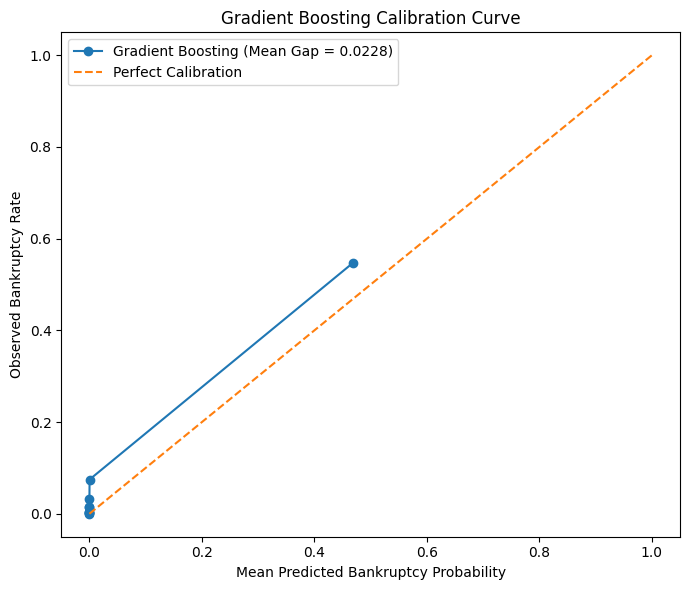

In [54]:
# Compare predicted bankruptcy probabilities with observed bankruptcy rates to visually assess whether the model is overconfident or underconfident

prob_true, prob_pred = calibration_curve(
    y_train,
    gb_oof_probabilities,
    n_bins=10,
    strategy="quantile"
)

uncalibrated_gap = np.mean(
    np.abs(prob_true - prob_pred)
)

fig, ax = plt.subplots(figsize=(7,6))

ax.plot(
    prob_pred,
    prob_true,
    marker="o",
    label=f"Gradient Boosting (Mean Gap = {uncalibrated_gap:.4f})"
)

ax.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Perfect Calibration"
)

ax.set_title("Gradient Boosting Calibration Curve")
ax.set_xlabel("Mean Predicted Bankruptcy Probability")
ax.set_ylabel("Observed Bankruptcy Rate")
ax.legend()

plt.tight_layout()
plt.show()

In [55]:
# Wrap the selected Gradient Boosting model with sigmoid probability calibration

calibrated_gradient_boosting = CalibratedClassifierCV(
    estimator=gradient_boosting_baseline,
    method="sigmoid",
    cv=5
)



In [56]:
#Generate leakage safe out of fold probabilities

calibrated_oof_probabilities = cross_val_predict(
    calibrated_gradient_boosting,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [57]:
#Compare raw and calibrated probability quality

calibration_comparison = pd.DataFrame({
    "Uncalibrated": {
        "Brier Score": brier_score_loss(
            y_train,
            gb_oof_probabilities
        ),
        "Log Loss": log_loss(
            y_train,
            gb_oof_probabilities
        ),
        "ROC-AUC": roc_auc_score(
            y_train,
            gb_oof_probabilities
        ),
        "PR-AUC": average_precision_score(
            y_train,
            gb_oof_probabilities
        )
    },
    "Sigmoid Calibrated":{
        "Brier Score": brier_score_loss(
            y_train,
            calibrated_oof_probabilities
        ),
        "Log Loss": log_loss(
            y_train,
            calibrated_oof_probabilities
        ),
        "ROC-AUC": roc_auc_score(
            y_train,
            calibrated_oof_probabilities
        ),
        "PR-AUC": average_precision_score(
            y_train,
            calibrated_oof_probabilities
        )
        
    }
}).T
calibration_comparison.round(4)

,Brier Score,Log Loss,ROC-AUC,PR-AUC
Uncalibrated,0.0320,0.2239,0.9484,0.7823
Sigmoid Calibrated,0.0282,0.1066,0.9565,0.7888


### Probability Calibration Findings

Sigmoid calibration improved the probabilistic quality of the selected Gradient Boosting Model.

Compared with the uncalibrated model:

- Brier Score decreased from 0.0320 to 0.0282,
- Log Loss decreased substantially from 0.2239 to 0.1066,
- ROC-AUC increased slightly from 0.9484 to 0.9565,
- PR-AUC increased slightly from 0.7823 to 0.7888.

The improvement in Brier Score and Log Loss indicates that the calibrated probabilities are more reliable as risk estimates. Because ranking performance was preserved while probabilistic quality improved, the sigmoid-calibrated Gradient Boosting model was retained for threshold selection and final evaluation.

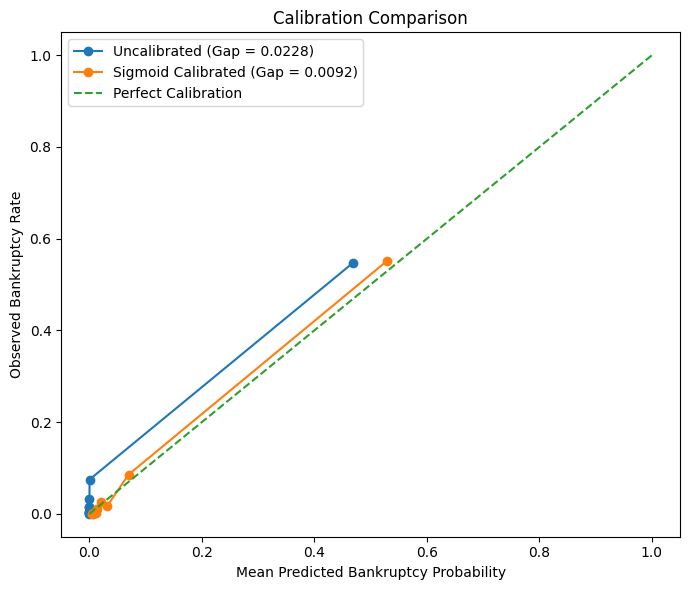

In [58]:
# Compare the calibration curves of the raw and sigmoid calibrated

uncal_true, uncal_pred = calibration_curve(
    y_train,
    gb_oof_probabilities,
    n_bins=10,
    strategy="quantile"
)

cal_true, cal_pred = calibration_curve(
    y_train,
    calibrated_oof_probabilities,
    n_bins=10,
    strategy="quantile"
)


uncalibrated_gap = np.mean(
    np.abs(uncal_true - uncal_pred)
)

calibrated_gap = np.mean(
    np.abs(cal_true - cal_pred)
)


fig, ax = plt.subplots(figsize=(7,6))

ax.plot(
    uncal_pred,
    uncal_true,
    marker="o",
    label=f"Uncalibrated (Gap = {uncalibrated_gap:.4f})"
)

ax.plot(
    cal_pred,
    cal_true,
    marker="o",
    label=f"Sigmoid Calibrated (Gap = {calibrated_gap:.4f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle = "--",
    label="Perfect Calibration"
)


ax.set_title("Calibration Comparison")
ax.set_xlabel("Mean Predicted Bankruptcy Probability")
ax.set_ylabel("Observed Bankruptcy Rate")
ax.legend()
plt.tight_layout()
plt.show()

In [59]:
# Calculate precision, recall and F1 score across probability threshold
precision_values, recall_values, thresholds, = precision_recall_curve(
    y_train,
    calibrated_oof_probabilities
)

calibrated_threshold_results = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision_values[:-1],
    "recall": recall_values[:-1]
})

calibrated_threshold_results["f1"] = (
    2 * calibrated_threshold_results["precision"] * calibrated_threshold_results["recall"] / (calibrated_threshold_results["precision"] + calibrated_threshold_results["recall"])
)

calibrated_threshold_results.head()

,threshold,precision,recall,f1
0,0.002649,0.069658,1.0,0.130244
1,0.002674,0.069673,1.0,0.130270
2,0.002698,0.069688,1.0,0.130296
3,0.002744,0.069703,1.0,0.130322
4,0.002775,0.069718,1.0,0.130348


In [60]:
# Identify the calibrated probability threshold that maximizes F1 using only out of fold training predictions

best_calibrated_f1 = calibrated_threshold_results.loc[
    calibrated_threshold_results["f1"].idxmax()
]

best_calibrated_f1.round(4)

threshold    0.2872
precision    0.7543
recall       0.6779
f1           0.7141
Name: 4383, dtype: float64

In [61]:
# Find the highest precision calibrated threshold that still captures at least 90% of bankrupt companies

high_recall_candidates = calibrated_threshold_results[calibrated_threshold_results["recall"] >= 0.90]

best_high_recall = (
    high_recall_candidates
    .sort_values(
        "precision",
        ascending=False
    )
    .iloc[0]
)

best_high_recall.round(4)

threshold    0.0489
precision    0.3564
recall       0.9018
f1           0.5109
Name: 3852, dtype: float64

In [62]:
#Compare default and tuned calibrated thresholds using the same out of fold predictions and business oriented classification outcomes.

calibrated_operating_thresholds = {
    "Default 0.50": 0.50,
    "F1-Optimal": best_calibrated_f1["threshold"],
    "Recall >= 90%": best_high_recall["threshold"]
}


calibrated_operating_results = []

for name, threshold in calibrated_operating_thresholds.items():
    predictions = (
        calibrated_oof_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        predictions
    ).ravel()

    calibrated_operating_results.append({
        "operating_point": name,
        "threshold": threshold,
        "precision": precision_score(y_train, predictions),
        "recall": recall_score(y_train, predictions),
        "f1": f1_score(y_train, predictions),
        "true_positive": tp,
        "false_positive": fp,
        "false_negative": fn,
        "true_negative": tn
    })

calibrated_operating_comparison = pd.DataFrame(
    calibrated_operating_results
)

calibrated_operating_comparison.round(4)

,operating_point,threshold,precision,recall,f1,true_positive,false_positive,false_negative,true_negative
0,Default 0.50,0.5000,0.8540,0.5920,0.6993,193,33,133,4321
1,F1-Optimal,0.2872,0.7543,0.6779,0.7141,221,72,105,4282
2,Recall >= 90%,0.0489,0.3564,0.9018,0.5109,294,531,32,3823


In [63]:
# Calculate how many companies would be flagged for review under each calibrated probability threshold

calibrated_operating_comparison["flagged_companies"] = (
    calibrated_operating_comparison["true_positive"] + calibrated_operating_comparison["false_positive"]
)

calibrated_operating_comparison["flagged_rate"] = (
    calibrated_operating_comparison["flagged_companies"] / len(y_train)
)

calibrated_operating_comparison[
    [
        "operating_point",
        "threshold",
        "precision",
        "recall",
        "f1",
        "flagged_companies",
        "flagged_rate",
        "false_positive",
        "false_negative"
    ]
].round(4)

,operating_point,threshold,precision,recall,f1,flagged_companies,flagged_rate,false_positive,false_negative
0,Default 0.50,0.5000,0.8540,0.5920,0.6993,226,0.0483,33,133
1,F1-Optimal,0.2872,0.7543,0.6779,0.7141,293,0.0626,72,105
2,Recall >= 90%,0.0489,0.3564,0.9018,0.5109,825,0.1763,531,32


### Final Threshold Selection

Three operating thresholds were evaluated using calibrated out of fold probabilities from training data.

The default threshold of 0.50 provided high precision but missed a relatively large number of bankrupt companies.

A low threshold designed to achieve at least 90% recall substantially reduced false negatives but generated a large number of false positive alerts and flagged approximately 17.6% of all companies.

The F1-optimal threshold of approximately 0.287 provided the most balanced
operating point:

- Precision: 0.7543
- Recall: 0.6779
- F1-score: 0.7141
- Flagged companies: 293 (6.26% of the training sample)
- False positives: 72
- False negatives: 105

Because no business-specific cost matrix was available, the F1-optimal threshold was selected as the final operating point.

In a production setting, the decision threshold should instead reflect the relative cost of false-positive alerts and missed bankruptcies.

In [64]:
# Fit the selected sigmoid calibrated Gradient Boosting model on the complete training dataset before final test evaluation

final_model = CalibratedClassifierCV(
    estimator=gradient_boosting_baseline,
    method="sigmoid",
    cv=5
)

final_model.fit(
    X_train,
    y_train
)

print("Final calibrated model fitted successfully")

Final calibrated model fitted successfully


In [65]:
# Generate bankruptcy probabilities for the untouched final test set.

test_probabilities = final_model.predict_proba(
    X_test
)[:, 1]

print(f"Test predictions: {len(test_probabilities):,}")

Test predictions: 1,170


In [66]:
#Evaluate final probability ranking and calibration performance 

final_probability_metrics = pd.Series({
    "ROC-AUC": roc_auc_score(
        y_test,
        test_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_test,
        test_probabilities
    ),
    "Brier Score": brier_score_loss(
        y_test,
        test_probabilities
    ),
    "Log Loss": log_loss(
        y_test,
        test_probabilities
    )
})


final_probability_metrics.round(4)

ROC-AUC        0.9745
PR-AUC         0.8579
Brier Score    0.0226
Log Loss       0.0867
dtype: float64

In [67]:
# Apply the F1 optimal probability threshold selected exclusively from calibrated out of fold training predictions

FINAL_THRESHOLD = float(
    best_calibrated_f1["threshold"]
)

test_predictions = (
    test_probabilities >= FINAL_THRESHOLD
).astype(int)

print(f"Final threshold: {FINAL_THRESHOLD:.4f}")

Final threshold: 0.2872


In [68]:
# Calculate the final threshold dependent classification metrics on the untouched test set.

final_classification_metrics = pd.Series({
    "Precision": precision_score(
        y_test,
        test_predictions
    ),
    "Recall": recall_score(
        y_test,
        test_predictions
    ),
    "F1": f1_score(
        y_test,
        test_predictions
    )
})

final_classification_metrics.round(4)

Precision    0.7471
Recall       0.7927
F1           0.7692
dtype: float64

In [69]:
# Calculate the final confusion matrix quantify correct predictions, false alarms and missed bankruptcy cases

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions
).ravel()

final_confusion_summary = pd.Series({
    "True Negatives": tn,
    "False Positives": fp,
    "False Negatives": fn,
    "True Positives": tp
})

final_confusion_summary

True Negatives     1066
False Positives      22
False Negatives      17
True Positives       65
dtype: int64

In [70]:
#Summarize the operational impact of the selected final threshold on the population

flagged_companies = int(
    test_predictions.sum()
)

flagged_rate = (
    flagged_companies / len(test_predictions)
)

print(f"Flagged companies: {flagged_companies}")
print(f"Flagged rate {flagged_rate:.2%}")

Flagged companies: 87
Flagged rate 7.44%


## Final Test Evaluation

After model selection probability calibration and threshold selection were completed exclusively using the training data, the final sigmoid calibrated Gradient Boosting model was evaluated once on the untouched test set.

### Probability Performance

The final model achieved:

- ROC-AUC: 0.9745
- PR-AUC: 0.8579
- Brier Score: 0.0226
- Log Loss: 0.0867

These results show strong ranking performance as well as reliable probability estimates.


### Classification Performance

Using the F1-optimal probability threshold of approximately 0.287, selected
from out-of-fold training predictions, the final test performance was:

- Precision: 0.7471
- Recall: 0.7927
- F1-score: 0.7692

The confusion matrix contained:

- 1,066 true negatives,
- 22 false positives,
- 17 false negatives,
- 65 true positives.


The model identified 65 of the 82 bankrupt companies in the untouched test set while generating 22 false positive risk alerts.

A total of 87 companies approximately 7.44% of the test population were flagged as high bankruptcy risk.

The final test set was not used to modify the selected model, calibration method, or probability threshold after these results were observed.

## Model Explainability with SHAP



In [71]:
import shap

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [72]:
# Fit a separate copy of the selected base Gradient Boosting estimator for the model interpretation

explainability_model = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=200,
    random_state=42
)

explainability_model.fit(
    X_train,
    y_train
)

print("Explainability model fitted successfully")

Explainability model fitted successfully


In [73]:
#Create a tree based SHAP explainer and calculate feature contributions for companies in the untouched test set

shap_explainer = shap.TreeExplainer(
    explainability_model
)

shap_values = shap_explainer(
    X_test
)

print(f"SHAP values shape: {shap_values.values.shape}")

SHAP values shape: (1170, 64)


In [74]:
#Calculate mean absolute SHAP values to measure each features overall contribution to Gradient Boosting predictions.

global_shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(
        shap_values.values
    ).mean(axis=0)
})

global_shap_importance = (
    global_shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

global_shap_importance.head(15)

,feature,mean_abs_shap
0,X27,1.199172
1,X21,1.080429
2,X34,0.882085
3,X46,0.600008
4,X58,0.497996
5,X35,0.440002
6,X25,0.391320
7,X39,0.373713
8,X36,0.290243
9,X24,0.265112


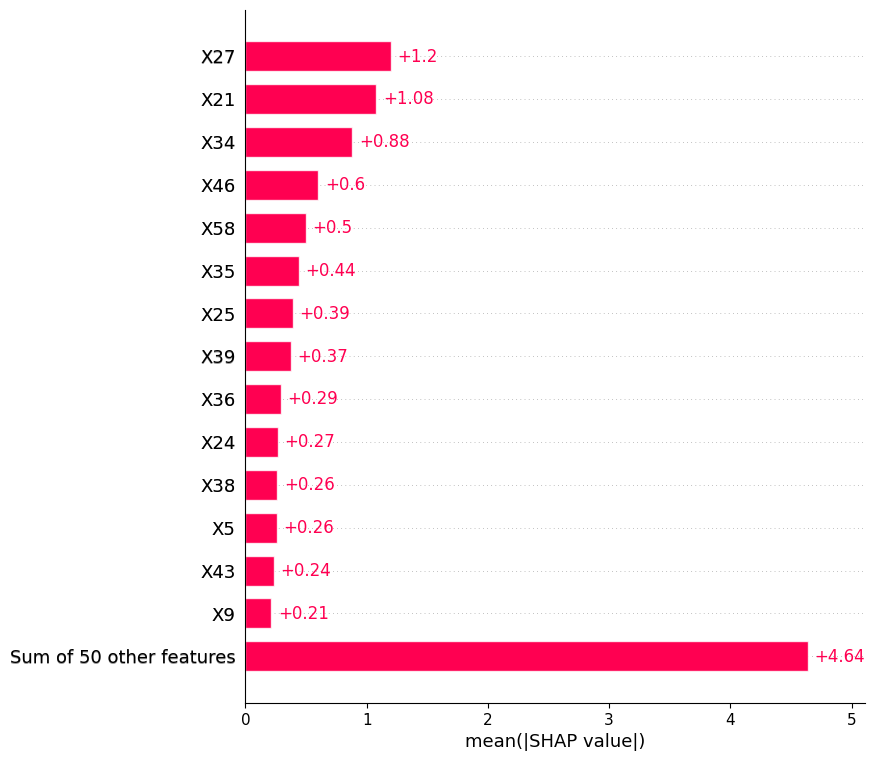

In [75]:
# Visualize the most influential financial features based on their average absolute SHAP contribution

shap.plots.bar(
    shap_values,
    max_display=15
)

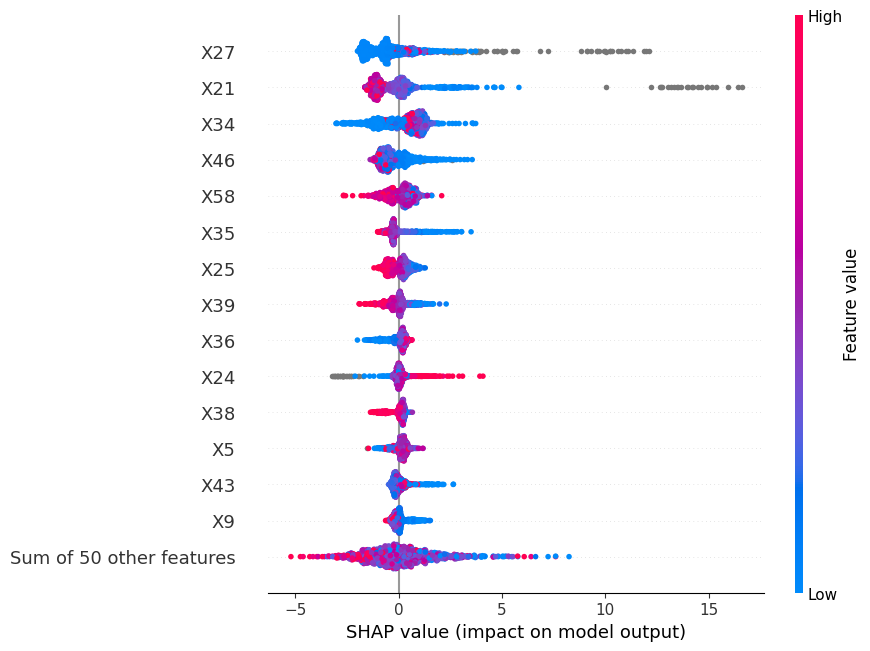

In [76]:
#Visualize both the magnitude and direction of feature effects across test companies using SHAP beeswarm plot.

shap.plots.beeswarm(
    shap_values,
    max_display=15
)

In [77]:
#Inspect where X21 ranks in the global SHAP importance table because its missingness showed an unusual bankruptcy association during EDA

x21_shap_rank = (
    global_shap_importance.reset_index()
)

x21_shap_rank["rank"] = (x21_shap_rank["index"] +1)

x21_shap_rank.loc[
    x21_shap_rank["feature"] == "X21",
    ["rank", "feature", "mean_abs_shap"]
]

,rank,feature,mean_abs_shap
1,2,X21,1.080429


### SHAP Findings

SHAP analysis shows that the Gradient Boosting model relies on a combination of financial ratios rather than a single dominant predictor.

The most influential individual features include X27, X21, X34, X46, X58, X35, and X25.

X21 ranks second in global SHAP importance. This confirms that X21 provides substantial predictive information while also showing that the model is not entirely dependent on the unusual X21 missingness.

SHAP shows that X21 and X27 can contribute positively to predicted bankruptcy risk.

In [78]:
#Identify test companies that were bankrupt and were correctly classified as high risk by the final calibrated model.

true_positive_positions = np.where(
    (y_test.to_numpy() == 1) & (test_predictions == 1)
)[0]

selected_position = true_positive_positions[
    np.argmax(
        test_probabilities[true_positive_positions]
    )
]

selected_index = X_test.index[selected_position]


print(f"Selected test position: {selected_position}")
print(f"Cleaned dataset row index: {selected_index}")
print(f"Actual class: {y_test.iloc[selected_position]}")
print(f"Calibrated bankruptcy probability: {test_probabilities[selected_position]:.2%}")
print(f"Final threshold: {FINAL_THRESHOLD:.4f}")

Selected test position: 741
Cleaned dataset row index: 5826
Actual class: 1
Calibrated bankruptcy probability: 99.39%
Final threshold: 0.2872


In [79]:
#Extract the largest positive and negative SHAP contributions for the selected true positive bankruptcy case

selected_shap_values = pd.DataFrame({
    "feature": X_test.columns,
    "feature_value": X_test.iloc[selected_position].values,
    "shap_value": shap_values.values[selected_position]
})

selected_shap_values["abs_shap"] = (selected_shap_values["shap_value"].abs())

selected_shap_values = (
    selected_shap_values.sort_values("abs_shap", ascending=False)
)

selected_shap_values.head(15)

,feature,feature_value,shap_value,abs_shap
20,X21,NaN,14.256772,14.256772
45,X46,0.14129,2.175543,2.175543
34,X35,-0.19030,1.675189,1.675189
26,X27,-8.71570,1.411853,1.411853
24,X25,-0.11316,0.747037,0.747037
33,X34,2.01720,0.664341,0.664341
57,X58,1.07400,-0.580303,0.580303
38,X39,-0.12603,0.572637,0.572637
4,X5,-44.53700,0.440299,0.440299
35,X36,1.60050,0.278598,0.278598


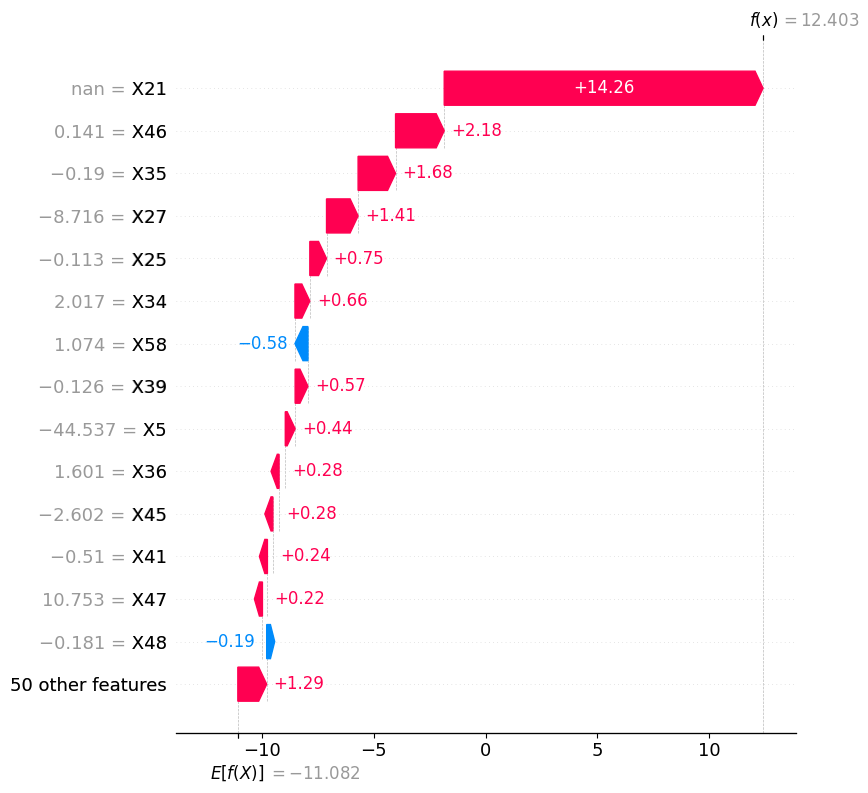

In [80]:
#Visualize how individual financial features move the selected companys base model output toward or away from higher bankruptcy risk

shap.plots.waterfall(
    shap_values[selected_position],
    max_display=15
)

### Local SHAP Case Study - High Risk True Positive

A true positive bankruptcy case was selected from the final test set for individual prediction analysis

The selected company:

- was actually classified as bankrupt,
- was correctly flagged as high risk by the final model,
- received a calibrated bankruptcy probability of 99.39%,
- was evaluated using the final operating threshold of approximately 0.287.

The SHAP explanation shows that the missing X21 value was by far the strongest contributor toward higher predicted bankruptcy risk for this company.

The other important risk increasing contributors included X46, X35, X27, X25 and X34.

This case shows that the model can combine multiple financial signals while also highlighting the unusually strong influence that X21 missingness can have for individual companies.

This example was deliberately selected as a high-confidence true-positive case for illustration and should not be interpreted as representative of all bankrupt companies.


In [81]:
#Display the features that contributed most strongly toward a higher bankruptcy risk prediction for the selected company

risk_increasing_features = (
    selected_shap_values[
        selected_shap_values["shap_value"] > 0
    ]
    .sort_values(
        "shap_value",
        ascending=False
    )
    .head(10)
)

risk_increasing_features[
    [
        "feature",
        "feature_value",
        "shap_value"
    ]
]

,feature,feature_value,shap_value
20,X21,NaN,14.256772
45,X46,0.14129,2.175543
34,X35,-0.19030,1.675189
26,X27,-8.71570,1.411853
24,X25,-0.11316,0.747037
33,X34,2.01720,0.664341
38,X39,-0.12603,0.572637
4,X5,-44.53700,0.440299
35,X36,1.60050,0.278598
44,X45,-2.60190,0.277176


In [82]:
#Display the features that contributed most strongly toward a lower bankruptcy risk prediction for the selected company

risk_reducing_features = (
    selected_shap_values[
        selected_shap_values["shap_value"] < 0
    ]
    .sort_values(
        "shap_value",
        ascending=True
    )
    .head(10)
)

risk_reducing_features[
    [
        "feature",
        "feature_value",
        "shap_value"
    ]
]

,feature,feature_value,shap_value
57,X58,1.074000,-0.580303
47,X48,-0.181050,-0.190620
48,X49,-0.119900,-0.185069
42,X43,79.524000,-0.158016
55,X56,-0.126080,-0.154763
59,X60,29.817000,-0.095500
8,X9,1.510000,-0.093263
14,X15,-4488.500000,-0.081130
30,X31,-0.078397,-0.074458
2,X3,-0.140900,-0.052187


In [83]:
#Identify true positive bankrupt companies where X21 is available

x21_present = X_test["X21"].notna().to_numpy()

true_positive_x21_present_positions = np.where(
    (y_test.to_numpy() == 1) & (test_predictions == 1) & x21_present
)[0]

selected_position_x21_present = (
    true_positive_x21_present_positions[
        np.argmax(
            test_probabilities[
                true_positive_x21_present_positions
            ]
        )
    ]
)

print(f"Selected test position: {selected_position_x21_present}")
print(f"Actual Class: {y_test.iloc[selected_position_x21_present]}")
print(f"X21 value: {X_test.iloc[selected_position_x21_present]['X21']}")
print(f"Calibrated bankruptcy probability: {test_probabilities[selected_position_x21_present]:.2%}")
print(f"Final threshold: {FINAL_THRESHOLD:.4f}")

Selected test position: 688
Actual Class: 1
X21 value: 0.806
Calibrated bankruptcy probability: 99.09%
Final threshold: 0.2872


In [84]:
#Extract the most influential SHAP contribution for a true positive company whose X21 value is observed rather than missing

selected_x21_present_shap = pd.DataFrame({
    "feature": X_test.columns,
    "feature_value": (
        X_test.iloc[
            selected_position_x21_present
        ].values
    ),
    "shap_value": (
        shap_values.values[
            selected_position_x21_present
        ]
    )
})    

selected_x21_present_shap["abs_shap"] = (
    selected_x21_present_shap["shap_value"].abs()
)

selected_x21_present_shap = (
    selected_x21_present_shap.sort_values("abs_shap", ascending=False)
)

selected_x21_present_shap.head(15)

,feature,feature_value,shap_value,abs_shap
26,X27,NaN,9.120103,9.120103
34,X35,-0.356220,1.331076,1.331076
33,X34,-0.150740,1.284779,1.284779
45,X46,0.040978,1.269767,1.269767
3,X4,0.177480,1.168850,1.168850
20,X21,0.806000,0.810139,0.810139
8,X9,0.768140,0.788015,0.788015
7,X8,-0.701220,0.786367,0.786367
38,X39,-0.300730,0.729546,0.729546
53,X54,-2.771900,0.679051,0.679051


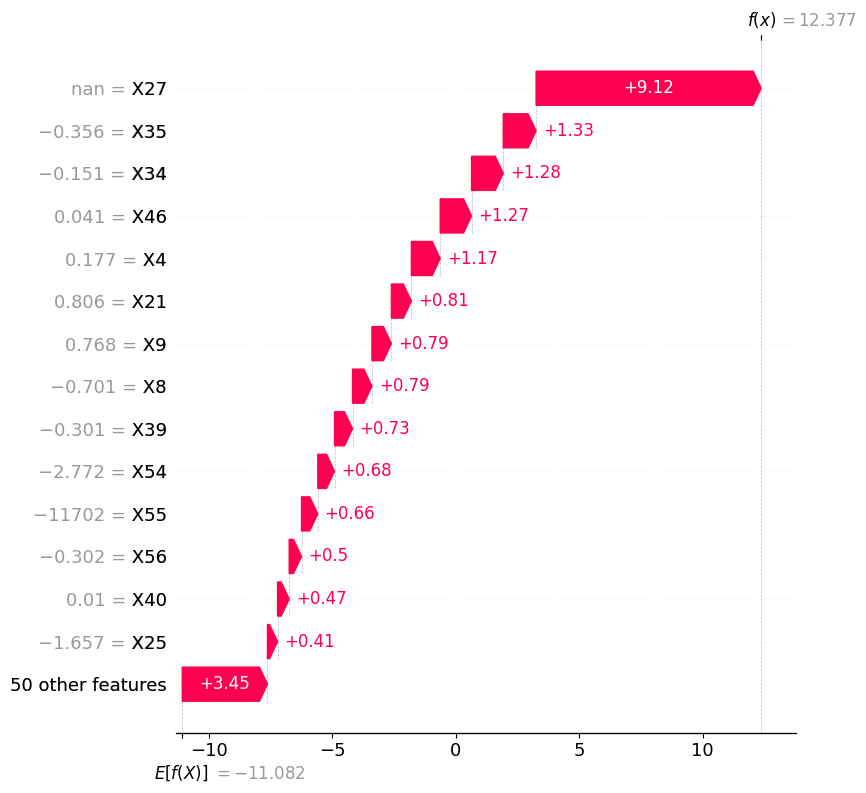

In [85]:
# Visualize the local financial drivers for a correctly identified  bankrupt company where X21 is not missing

shap.plots.waterfall(
    shap_values[
        selected_position_x21_present
    ],
    max_display=15
)

### Local SHAP Case Study — X21 Available

A second true-positive bankruptcy case was selected to evaluate whether the model could identify high-risk companies when X21 was available rather than missing.

The selected company:

- was actually bankrupt,
- had an observed X21 value of 0.806,
- received a calibrated bankruptcy probability of 99.09%,
- was correctly classified using the final threshold of approximately 0.287.

In this case, X21 was not the dominant risk driver. Instead, the missing X27 value produced the largest positive SHAP contribution.

Additional financial variables including X35, X34, X46, X4, X9, X8, and X39 also contributed toward higher predicted bankruptcy risk.

This example confirms that the model does not require X21 to be missing in order to generate a high-risk bankruptcy prediction.

Both local examples were deliberately selected as high-confidence true-positive cases for illustration. They are not intended to represent the full distribution of bankrupt companies.

In [86]:
# Remove the 2 features with the largest missingness driven SHAP patterns to evaluate how much predictive performance remains without these signals.


X_train_without_x21_x27 = X_train.drop(columns=["X21", "X27"])

gb_without_x21_x27_results = cross_validate(
    gradient_boosting_baseline,
    X_train_without_x21_x27,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

gb_without_x21_x27_folds = pd.DataFrame({
    "ROC-AUC": gb_without_x21_x27_results["test_roc_auc"],
    "PR-AUC": gb_without_x21_x27_results["test_pr_auc"],
    "Precision": gb_without_x21_x27_results["test_precision"],
    "Recall": gb_without_x21_x27_results["test_recall"],
    "F1": gb_without_x21_x27_results["test_f1"]    
})

gb_without_x21_x27_folds.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
0,0.8762,0.4813,0.6667,0.3385,0.4490
1,0.9124,0.4981,0.6000,0.2769,0.3789
2,0.8737,0.5068,0.6667,0.3385,0.4490
3,0.8918,0.5254,0.8148,0.3385,0.4783
4,0.9142,0.6185,0.7097,0.3333,0.4536


In [87]:
# Summarize model performance after removing both X21 and X27

gb_without_x21_x27_summary = pd.DataFrame({
    "mean": gb_without_x21_x27_folds.mean(),
    "std": gb_without_x21_x27_folds.std()
})

gb_without_x21_x27_summary.round(4)

,mean,std
ROC-AUC,0.8936,0.0193
PR-AUC,0.5260,0.0541
Precision,0.6916,0.0793
Recall,0.3251,0.0270
F1,0.4418,0.0372


In [88]:
# Compare the full Gradient Boosting model with sensitivity models that exclude the strongest missingness features

missingness_sensitivity_comparison = pd.DataFrame({
    "Gradient Boosting": gb_cv_folds.mean(),
    "No X21": gb_without_x21_folds.mean(),
    "No X21 and X27": gb_without_x21_x27_folds.mean()
}).T


missingness_sensitivity_comparison.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
Gradient Boosting,0.9497,0.7847,0.8781,0.5675,0.6880
No X21,0.9466,0.7066,0.8133,0.4816,0.6041
No X21 and X27,0.8936,0.5260,0.6916,0.3251,0.4418


### Missingness Robustness Analysis

Post hoc SHAP analysis identified X27 and X21 as the two most influential individual features in the selected Gradient Boosting model.

Performance changed as follows:

| Model | ROC-AUC | PR-AUC | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|
| Gradient Boosting | 0.9497 | 0.7847 | 0.8781 | 0.5675 | 0.6880 |
| Without X21 | 0.9466 | 0.7066 | 0.8133 | 0.4816 | 0.6041 |
| Without X21 and X27 | 0.8936 | 0.5260 | 0.6916 | 0.3251 | 0.4418 |


Removing X21 alone caused only a small reduction in ROC-AUC, although minority-class performance declined more noticeably.

Removing both X21 and X27 produced a larger reduction in PR-AUC, recall, and F1-score. This indicates that the model derives substantial predictive value from these variables and their missingness patterns.

These sensitivity experiments were conducted after the final model and test  evaluation had already been completed. They were used only to understand model behavior and were not used to modify the selected model, calibration method, threshold, or reported test performance.

## Final Model Performance Visualization

This section visualizes the final sigmoid-calibrated Histogram Gradient Boosting model on the untouched test set using the selected operating threshold.

The final threshold is applied to the calibrated bankruptcy probabilities to convert them into class predictions. The confusion matrix summarizes how many bankrupt and non bankrupt companies were correctly and incorrectly classified. The metric chart complements this by showing the final test set ROC-AUC, PR-AUC, Precision, Recall and F1 score

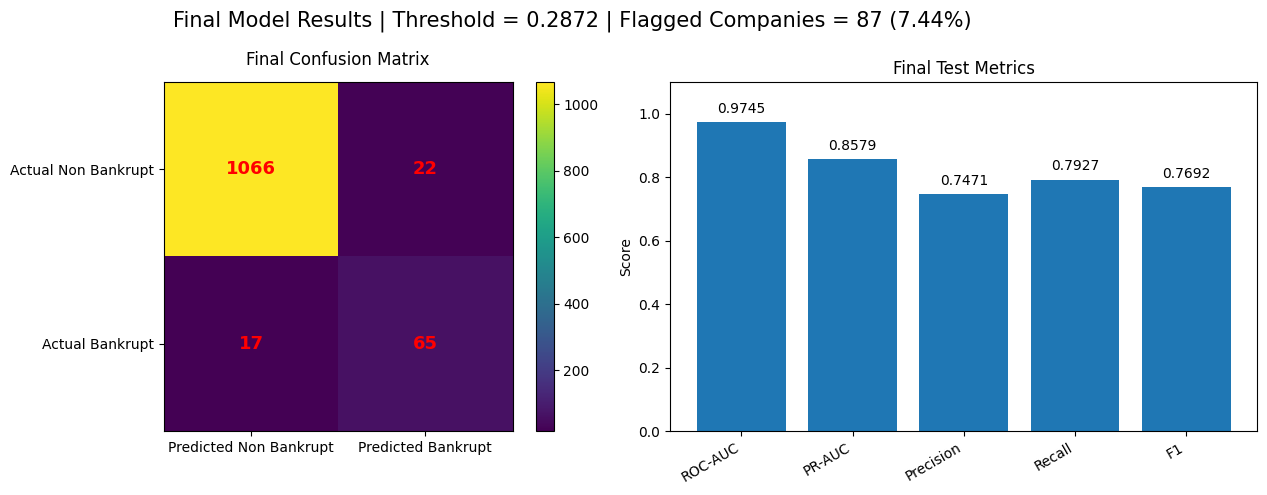

In [89]:
#Final model performance visualization on the untouched test set


final_metric_plot = pd.Series({
    "ROC-AUC": final_probability_metrics["ROC-AUC"],
    "PR-AUC": final_probability_metrics["PR-AUC"],
    "Precision": final_classification_metrics["Precision"],
    "Recall": final_classification_metrics["Recall"],
    "F1": final_classification_metrics["F1"]    
})


cm = np.array([
    [
        final_confusion_summary["True Negatives"],
        final_confusion_summary["False Positives"]
    ],
    [
        final_confusion_summary["False Negatives"],
        final_confusion_summary["True Positives"]
    ]
])

fig, axes = plt.subplots(1, 2, figsize=(14,5))


## Left part 

ax = axes[0]
im = ax.imshow(cm)

ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(["Predicted Non Bankrupt", "Predicted Bankrupt"])
ax.set_yticklabels(["Actual Non Bankrupt", "Actual Bankrupt"])
ax.set_title("Final Confusion Matrix", pad=12)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, f"{cm[i,j]}",
            ha="center", va="center",
            color="red", fontsize=13, fontweight="bold"
        )
fig.colorbar(im, ax=ax, fraction = 0.04, pad = 0.04)


# Right part

ax2 = axes[1]
bars = ax2.bar(final_metric_plot.index, final_metric_plot.values)

ax2.set_ylim(0, 1.1)
ax2.set_title("Final Test Metrics")
ax2.set_ylabel("Score")
ax2.set_xticks(range(len(final_metric_plot.index)))
ax2.set_xticklabels(final_metric_plot.index, rotation=30, ha="right")


for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )


fig.suptitle(
    f"Final Model Results | "
    f"Threshold = {FINAL_THRESHOLD:.4f} | "
    f"Flagged Companies = {flagged_companies} ({flagged_rate:.2%})",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Final Visualization Findings

The metric chart confirms that the final model combines strong ranking ability with solid threshold-based classification performance:
- ROC-AUC: 0.9745
- PR-AUC: 0.8579
- Precision: 0.7471
- Recall: 0.7927
- F1-score: 0.7692

Overall, the final operating point provides a practical balance between capturing bankrupt companies and limiting unnecessary investigations.

# Modeling Summary

## Data Integrity and Leakage Control

The modeling workflow began with explicit validation of the predictor schema.

During model development, an accidental row-index feature was identified as a potential source of target leakage because the source dataset was ordered by bankruptcy class.

The index feature was permanently excluded, and the modeling matrix was explicitly validated to contain only the expected X1-X64 financial features.
## Model Comparison

Several classification approaches were evaluated using stratified 5-fold cross-validation:

- DummyClassifier,
- Logistic Regression,
- Logistic Regression with missing-value indicators,
- Random Forest,
- Histogram Gradient Boosting,
- XGBoost.


Because bankrupt companies represent only approximately 7% of observations, PR-AUC was treated as the primary model selection metric.

Histogram Gradient Boosting achieved the strongest cross-validation performance:

- ROC-AUC: 0.9497
- PR-AUC: 0.7847
- Precision: 0.8781
- Recall: 0.5675
- F1-score: 0.6880

It slightly outperformed XGBoost while remaining relatively stable across validation folds.

## Probability Calibration

Sigmoid calibration was applied to the selected Gradient Boosting model.

Using out-of-fold training predictions, calibration improved:

- Brier Score from 0.0320 to 0.0282,
- Log Loss from 0.2239 to 0.1066,

The calibrated model was retained for final risk estimation.

## Threshold Selection

The default 0.50 classification threshold was compared with alternative operating points using calibrated out of fold training probabilities. Because no explicit business cost matrix was available the threshold that maximized F1 score was selected.

The final threshold was approximately:

**0.2872**

## Final Test Performance

Final probability performance:

- ROC-AUC: 0.9745
- PR-AUC: 0.8579
- Brier Score: 0.0226
- Log Loss: 0.0867

Final classification performance:

- Precision: 0.7471
- Recall: 0.7927
- F1-score: 0.7692

The confusion matrix contained:

- 1,066 true negatives,
- 22 false positives,
- 17 false negatives,
- 65 true positives.

A total of 87 companies, approximately 7.44% of the test population, were flagged as high bankruptcy risk.


## Model Explainability

SHAP analysis was applied to the underlying Histogram Gradient Boosting estimator.

The most influential individual predictors included:

- X27,
- X21,
- X34,
- X46,
- X58,
- X35,
- X25,
- X39.

Local SHAP case studies showed that:

- one high-risk true-positive prediction was strongly influenced by missing X21,
- another high-risk true-positive company had X21 available but was strongly
  influenced by missing X27 and several other financial ratios.

This confirms that the model is not based on a single feature although missing data patterns represent an important source of predictive information.

## Limitations

First, the dataset is historical and bankruptcy represents a small minority class, which limits the number of positive examples available for validation and testing.

Second, missingness is highly informative for some financial variables, particularly X21 and X27. These patterns may reflect genuine financial distress, reporting behavior, data-collection mechanisms, or dataset-specific artifacts. Their reliability should therefore be validated before using the model in a production environment.

Third, correlated financial ratios contain overlapping information, and SHAP importance should not be interpreted as causal financial relationships.

Fourth, the final threshold was selected by maximizing F1-score because no business-specific cost matrix was available. A production system should choose its operating threshold according to the relative cost of missed bankruptcies and false-positive risk alerts.

Finally, the final holdout test set contains only 82 bankrupt companies. Although test performance was strong, evaluation on additional companies, time periods, and external datasets would be necessary before deployment.

The bankrupt and operating companies were collected from partially different calendar periods. As a result, a random train-test split may not fully measure generalization across time and may capture some cohort-specific patterns.

A production-oriented validation should therefore include temporal or external holdout data in addition to random stratified validation.

## Conclusion 

This project demonstrates an end to end bankruptcy prediction workflow that includes data quality investigation, leakage detection, imbalanced classification, model comparison, probability calibration, threshold selection, final holdout evaluation, sensitivity analysis and SHAP based interpretability.

The final sigmoid-calibrated Histogram Gradient Boosting model achieved strong predictive performance on the untouched test set while retaining a transparent analysis of the dataset-specific risks and limitations that influence its predictions.
